# Vision Transformers

## Install packages

In [1]:
import torch 
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets

In [13]:
from torch.utils.data import DataLoader

In [2]:
import torchinfo as ti

In [4]:
from pathlib import Path
import os 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Path to the data

In [6]:
image_path = Path(".") / "data" / "pizza_steak_suchi"

In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

## Transforms, Dataset and DataLoaders

In [9]:
transform_train = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [11]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_train)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform_test)

In [14]:
# DataLoader

train_dataloader = DataLoader(dataset=train_dataset, 
                              batch_size=32, 
                              shuffle=True, 
                              pin_memory=True, 
                              prefetch_factor= 2,
                              num_workers=os.cpu_count()-4
                              )

test_dataloader = DataLoader(dataset=test_dataset, 
                             batch_size=32, 
                             pin_memory=True, 
                             prefetch_factor=2, 
                             num_workers=os.cpu_count()-4)

In [16]:
img, label = next(iter(train_dataloader))

/Users/maximecollet/Desktop/PyTorch/ZTM_nb/Learning_PyTorch/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [18]:
image, label = img[0], label[0]

In [26]:
classes = train_dataset.classes

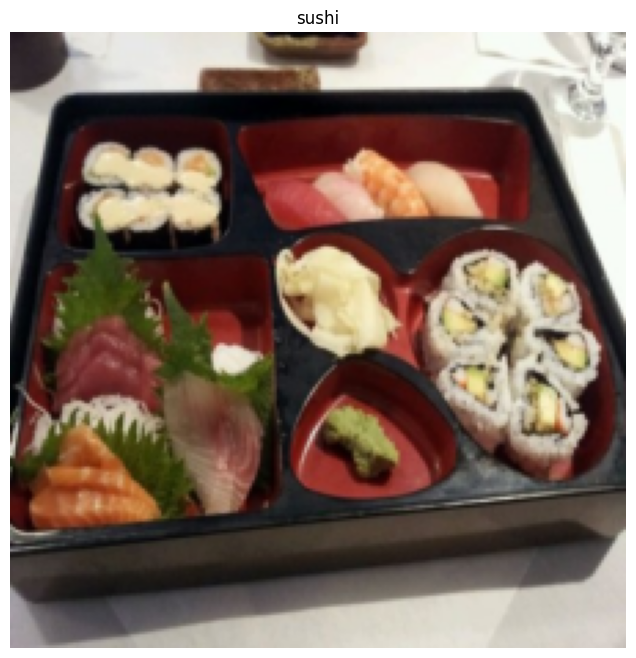

In [27]:
plt.figure(figsize=(12,8))
plt.imshow(image.permute(1,2,0))
plt.title(f"{classes[label]}")
plt.axis(False)
plt.show()